## Shranimo cleaned in pripravimo vektorje

očiščene df shrani v mapo cleaned (vsebuje y in -y), poračuna dolžino skokov za vsak polet, vektorje s komponentami iz vsakega poleta-2. element (1. data vrstica) iz vsakega file

In [2]:
import os
import math
import pandas as pd
from flatten_wind import *

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'
clean_folder = os.path.join(folder_path, "cleaned")
os.makedirs(clean_folder, exist_ok=True)

column_vectors = {}
lengths = []

# Loop through all CSV files
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)

        try:
            # Read original CSV (semicolon-separated)
            df = pd.read_csv(file_path, delimiter=';')

            # Extract and flatten wind blob
            wind_col_name = df.columns[-1]
            wind_df = df[wind_col_name].apply(flatten_wind_blob)
            df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

            if "Time" in df_cleaned.columns:
                df_cleaned["Time"] = df_cleaned["Time"].apply(timestamp_to_seconds)

            df_cleaned["Y [m]"] = df_cleaned["Y [m]"].astype(float)
            if df_cleaned["Y [m]"].iloc[-1] >= 0:
                df_cleaned["Y [m]"] = -df_cleaned["Y [m]"]

            # Save cleaned file
            cleaned_filename = os.path.splitext(filename)[0] + "_cleaned.csv"
            cleaned_path = os.path.join(clean_folder, cleaned_filename)
            df_cleaned.to_csv(cleaned_path, index=False)


            #lengths
            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")

            selected_columns = df_cleaned.columns[16:]

            # veter vektorji
            if len(df_cleaned) > 1:
                values = df_cleaned.loc[1, selected_columns]

                for col in selected_columns:
                    val = values[col]
                    if col not in column_vectors:
                        column_vectors[col] = []
                    column_vectors[col].append(float(val))

        except Exception as e:
            print(f"Error processing {filename}: {e}")

print("Extracted vectors:")
for col, vec in column_vectors.items():
    print(f"{col} ({len(vec)} values): {vec[:5]}...")
lengths


Extracted vectors:
W1_Speed (199 values): [0.5, 0.8, 1.3, 0.9, 0.4]...
W1_Tangent (199 values): [0.45, 0.49, 1.07, 0.11, 0.07]...
W1_Turbulence (199 values): [0.01, 0.04, 0.11, 0.11, 0.01]...
W1_CleanTan (199 values): [0.45, 0.49, 1.07, 0.11, 0.07]...
W1_Cross (199 values): [0.14, 0.51, 0.63, 0.94, 0.39]...
W2_Speed (199 values): [1.2, 0.9, 2.6, 1.1, 0.6]...
W2_Tangent (199 values): [0.64, 0.82, 2.27, -0.51, -0.22]...
W2_Turbulence (199 values): [0.19, 0.02, 0.44, 0.08, 0.13]...
W2_CleanTan (199 values): [0.64, 0.82, 2.27, -0.51, -0.22]...
W2_Cross (199 values): [0.84, 0.34, 1.02, 0.5, 0.48]...
W3_Speed (199 values): [0.8, 1.2, 1.6, 0.5, 1.4]...
W3_Tangent (199 values): [0.55, 0.67, 1.22, -0.01, 0.89]...
W3_Turbulence (199 values): [0.09, 0.02, 0.2, 0.0, 0.06]...
W3_CleanTan (199 values): [0.55, 0.67, 1.22, -0.01, 0.89]...
W3_Cross (199 values): [0.5, 0.85, 0.38, 0.45, 0.98]...
W4_Speed (199 values): [1.9, 2.1, 1.3, 0.8, 2.4]...
W4_Tangent (199 values): [0.66, 1.14, -0.65, -0.16, -0.59

[207.11879248392697,
 199.7606487774807,
 229.29820845353328,
 213.45253149119594,
 211.1778513480995,
 233.2731467614736,
 203.54295099560682,
 195.45360805060622,
 203.56941666173728,
 219.36577148680237,
 199.45385932591026,
 223.7171949135783,
 221.80018687999342,
 216.59870059628707,
 197.45661877992342,
 164.01528130024957,
 196.2939583889428,
 210.1301896444202,
 212.66576663863887,
 191.08984405247705,
 185.66868583581885,
 185.18171913015607,
 171.8737126497243,
 219.07254049743435,
 209.02252964692585,
 203.66466188320447,
 193.23749144511268,
 186.48818166307484,
 181.35469500401692,
 186.14512026910617,
 188.63729959899234,
 138.3992850415059,
 185.05998405922335,
 165.4204334415794,
 183.82165215229676,
 117.90960859912987,
 179.474739448202,
 179.88638358697415,
 212.84268509864276,
 186.20930723247966,
 194.77093520338195,
 194.16780732139918,
 172.05544629566367,
 224.37627548383986,
 195.01349312291188,
 154.47517923601836,
 202.44276697377953,
 210.62507756675132,
 21

## Top 5 korelacij

In [5]:
import pandas as pd

fixed_vector = pd.Series(lengths)  #fiksiramo vektor za njegovo primerjvao
correlations = []

for name, values in column_vectors.items():
    try:
        vec_series = pd.Series(values)
        corr = fixed_vector.corr(vec_series)
        correlations.append((name, corr))
        
    except Exception as e:
        print(f"Error with vector {name}: {e}")

# Sort by absolute value of correlation
correlations_sorted = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)

print("Top 5 vectors by absolute correlation:")
for name, corr in correlations_sorted[:5]:
    print(f"{name}: correlation = {corr:.4f}")


Top 5 vectors by absolute correlation:
W10_Speed: correlation = 0.3059
W5_Tangent: correlation = 0.2292
W5_CleanTan: correlation = 0.2292
W5_Speed: correlation = 0.2254
W11_Tangent: correlation = 0.2222


povprečna korelacija:

In [9]:
vsota = 0
for name, corr in correlations_sorted:
    vsota += corr
print(vsota / len(correlations_sorted))

0.08796534516729788


## vizualizacija

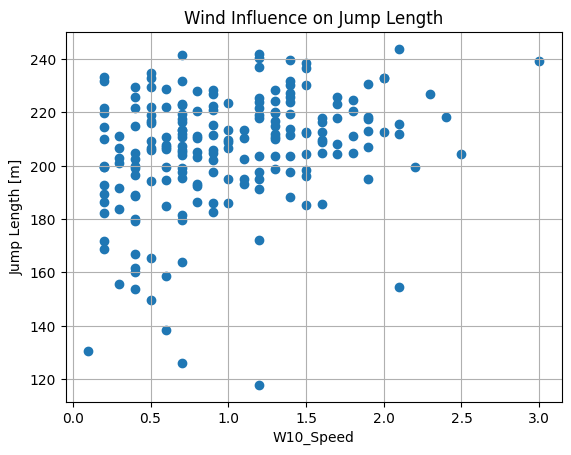

In [10]:
import matplotlib.pyplot as plt

plt.scatter(column_vectors["W10_Speed"], lengths)
plt.xlabel("W10_Speed")
plt.ylabel("Jump Length [m]")
plt.title("Wind Influence on Jump Length")
plt.grid(True)
plt.show()


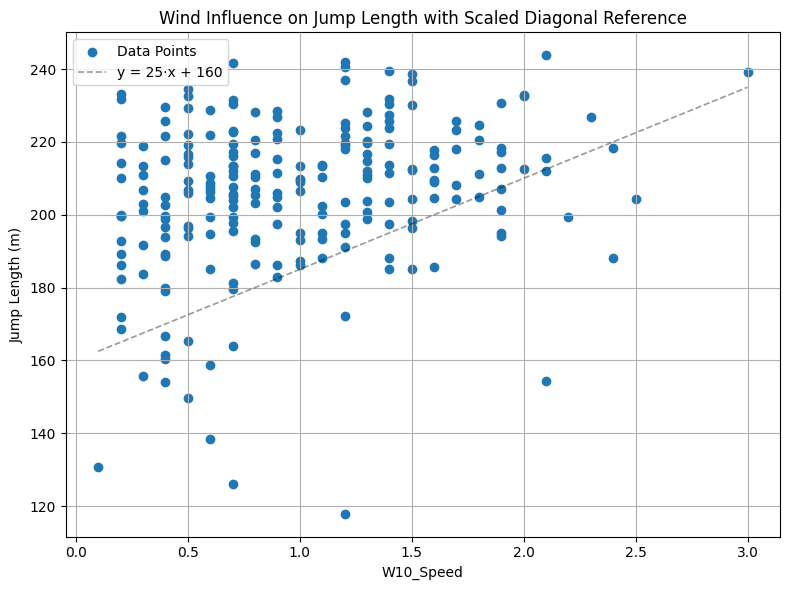

In [ ]:
import matplotlib.pyplot as plt

x = column_vectors["W10_Speed"]
y = lengths

#Parametri za linearn reference
scale = 25     
offset = 160

plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Data Points', alpha=1)

x_line = [min(x), max(x)]
y_line = [scale * val + offset for val in x_line]
plt.plot(x_line, y_line, 'k--', linewidth=1.2, alpha=0.4, label=f'y = {scale}·x + {offset}')

plt.xlabel("W10_Speed")
plt.ylabel("Jump Length (m)")
plt.title("Wind Influence on Jump Length with Scaled Diagonal Reference")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


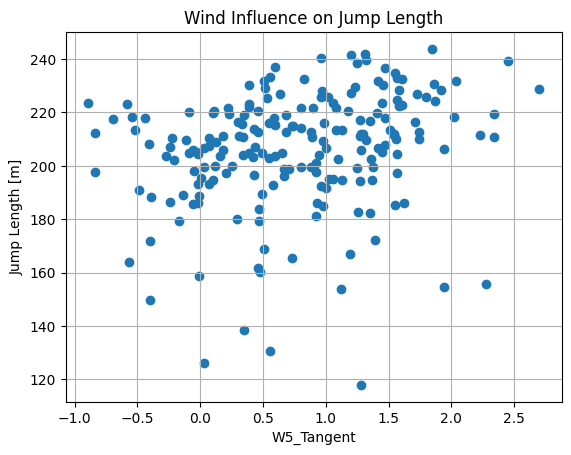

In [11]:
import matplotlib.pyplot as plt

plt.scatter(column_vectors["W5_Tangent"], lengths)
plt.xlabel("W5_Tangent")
plt.ylabel("Jump Length [m]")
plt.title("Wind Influence on Jump Length")
plt.grid(True)
plt.show()

## Sample iz samo top tier data

s prejšnjo kodo shraniš cleaned2, pol pa se sprehodš po seznamu 2eh točk iz vsake cone in korelacijske vektorje za vsako točko shranš v svoj csv file. Torej vsak file vsebuje vse vrednosti (npr W1_speed) ob določenem času. 

In [13]:
import os
import math
import pandas as pd
from flatten_wind import *

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned2'
new_folder = "correlation_vectors"
os.makedirs(new_folder, exist_ok=True)

lengths = []
points = [1, 10, 55, 65, -10, -1]
dict_list = [{} for _ in points]

# Loop through all CSV files
for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")

            selected_columns = df.columns[16:].insert(0, "Speed hor. [km/h]")    #na 0. mesto dodej 13...index hor. speed

            for i, point in enumerate(points):
                if "dict_id" not in dict_list[i]:
                            dict_list[i]["dict_id"] = []
                dict_list[i]["dict_id"].append(f"{point}" + ". point")
                if "length" not in dict_list[i]:
                            dict_list[i]["length"] = []
                dict_list[i]["length"].append(length)

                if len(df) > 1:
                    values = df.loc[df.index[point], selected_columns]

                    for col in selected_columns:
                        val = values[col]
                        if col not in dict_list[i]:
                            dict_list[i][col] = []
                        dict_list[i][col].append(float(val))
                    
        except Exception as e:
            print(f"Error processing {filename}: {e}")
                    
for i, point in enumerate(dict_list):
    df2 = pd.DataFrame(point)
    df2.to_csv(os.path.join(new_folder, f"point_{points[i]}" + ". point.csv"), index=False)
    print(f"vectors saved for point {points[i]}")



vectors saved for point 1
vectors saved for point 10
vectors saved for point 55
vectors saved for point 65
vectors saved for point -10
vectors saved for point -1


In [12]:
import pandas as pd

data_path = r"C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors\point_1. point.csv"
df = df = pd.read_csv(data_path, delimiter=',')

corr = df["Speed hor. [km/h]"].corr(df['W12_Tangent'])

print(f"Correlation between Speed and Wind: {corr:.4f}")


Correlation between Speed and Wind: -0.4426


Radi bi pogledali, če so senzorji vetrov res v pravih conah: Torej za vsako točko pogledamo horizontalno hitrist skakalca in primerjamo njeno korelacijo z vetrovi, če je senzor v pravi coni, potem bo imela hitrost najvišjo korelacijo s senzorji v tisti coni. Npr. povprečje hitrosti skakalca na čistem začetku (v prvih dveh točkah) naj bi imelo najvišjo korelacijo pri senzorjih W1-W3.

In [14]:
import pandas as pd
import os
from collections import defaultdict

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors'
main = "Speed hor. [km/h]"

# naredimo slovar z seznami za vsako cono
group_correlations = {
    1: defaultdict(list),
    2: defaultdict(list),
    3: defaultdict(list)
}

for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            # Remove non-numeric columns
            df = df.select_dtypes(include=['number'])

            if main not in df.columns:
                print(f"Column '{main}' not found in {filename}. Skipping...")
                continue

            fixed_vector = df[main]
            df = df.drop(columns=[main])
            columns = list(df.columns)

            #ratdekimo v skupine
            pairs = [(i, i + 1) for i in range(0, len(columns), 2)]
            total_pairs = len(pairs)
            group_size = total_pairs // 3

            groups = {
                1: pairs[:group_size],
                2: pairs[group_size:2 * group_size],
                3: pairs[2 * group_size:]
            }

            # Compute correlations for each group
            for g, pair_list in groups.items():
                for (i1, i2) in pair_list:
                    if i1 < len(columns):
                        col1 = columns[i1]
                        try:
                            corr1 = fixed_vector.corr(df[col1])
                            group_correlations[g][col1].append(corr1)
                        except Exception as e:
                            print(f"Error computing correlation for {col1} in group {g}: {e}")

                    if i2 < len(columns):
                        col2 = columns[i2]
                        try:
                            corr2 = fixed_vector.corr(df[col2])
                            group_correlations[g][col2].append(corr2)
                        except Exception as e:
                            print(f"Error computing correlation for {col2} in group {g}: {e}")

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# izračunamo povprečje
avg_group_correlations = {
    g: {var: sum(vals) / len(vals) for var, vals in variables.items() if vals}
    for g, variables in group_correlations.items()
}

print("\n=== Top 5 variables by average absolute correlation for each zone ===")
for g in avg_group_correlations:
    print(f"\nGroup {g}:")
    sorted_vars = sorted(avg_group_correlations[g].items(), key=lambda x: abs(x[1]), reverse=True)
    for var, avg_corr in sorted_vars[:5]:
        print(f"  {var}: avg correlation = {avg_corr:.4f}")



=== Top 5 variables by average absolute correlation for each zone ===

Group 1:
  W3_Tangent: avg correlation = -0.3415
  W3_CleanTan: avg correlation = -0.3415
  W1_Tangent: avg correlation = -0.3175
  W1_CleanTan: avg correlation = -0.3175
  W1_Cross: avg correlation = 0.3100

Group 2:
  W8_Tangent: avg correlation = -0.4810
  W8_CleanTan: avg correlation = -0.4810
  W7_Tangent: avg correlation = -0.4257
  W7_CleanTan: avg correlation = -0.4257
  W6_Tangent: avg correlation = -0.4096

Group 3:
  W12_Tangent: avg correlation = -0.4610
  W12_CleanTan: avg correlation = -0.4610
  W9_Tangent: avg correlation = -0.4532
  W9_CleanTan: avg correlation = -0.4532
  W10_Tangent: avg correlation = -0.4187


Opazimo da so senzorji vetra nastavljeni pravilno.

### sample iz pozitivnih Y (oz. prave Y * (-1))

Najprej isto shranimo v cleaned_negativeY, kjer skippamo vse ki že imajo negativno višino na koncu poleta.

In [ ]:
import os
import math
import pandas as pd
from flatten_wind import *

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'
clean_folder = os.path.join(folder_path, "cleaned_negativeY")
os.makedirs(clean_folder, exist_ok=True)

column_vectors = {}
lengths = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=';')

            wind_col_name = df.columns[-1]
            wind_df = df[wind_col_name].apply(flatten_wind_blob)
            df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

            if "Time" in df_cleaned.columns:
                df_cleaned["Time"] = df_cleaned["Time"].apply(timestamp_to_seconds)

            df_cleaned["Y [m]"] = df_cleaned["Y [m]"].astype(float)
            if df_cleaned["Y [m]"].iloc[-1] < 0:
                continue

            cleaned_filename = os.path.splitext(filename)[0] + "_cleaned_negativeY.csv"
            cleaned_path = os.path.join(clean_folder, cleaned_filename)
            df_cleaned.to_csv(cleaned_path, index=False)

        except Exception as e:
            print(f"Error processing {filename}: {e}")


korelacijski vektorji

In [15]:
import os
import math
import pandas as pd
from flatten_wind import *

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned_negativeY'
new_folder = "correlation_vectors_negativeY"
os.makedirs(new_folder, exist_ok=True)

lengths = []
points = [1, 10, 55, 65, -10, -1]
dict_list = [{} for _ in points]

# Loop through all CSV files
for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")

            selected_columns = df.columns[16:].insert(0, "Speed hor. [km/h]")    #na 0. mesto dodej 13...index hor. speed

            for i, point in enumerate(points):
                if "dict_id" not in dict_list[i]:
                            dict_list[i]["dict_id"] = []
                dict_list[i]["dict_id"].append(f"{point}" + ". point")
                if "length" not in dict_list[i]:
                            dict_list[i]["length"] = []
                dict_list[i]["length"].append(length)

                if len(df) > 1:
                    values = df.loc[df.index[point], selected_columns]

                    for col in selected_columns:
                        val = values[col]
                        if col not in dict_list[i]:
                            dict_list[i][col] = []
                        dict_list[i][col].append(float(val))
                    
        except Exception as e:
            print(f"Error processing {filename}: {e}")
                    
for i, point in enumerate(dict_list):
    df2 = pd.DataFrame(point)
    df2.to_csv(os.path.join(new_folder, f"point_{points[i]}" + ". point.csv"), index=False)
    print(f"vectors saved for point {points[i]}")


vectors saved for point 1
vectors saved for point 10
vectors saved for point 55
vectors saved for point 65
vectors saved for point -10
vectors saved for point -1


preverimo ali so podatki o vetru na pravem mestu, glede na to, da moramo višino množiti z -1

In [ ]:
import pandas as pd
import os
from collections import defaultdict

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors_negativeY'
main = "Speed hor. [km/h]"

group_correlations = {
    1: defaultdict(list),
    2: defaultdict(list),
    3: defaultdict(list)
}

for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            # Remove non-numeric columns
            df = df.select_dtypes(include=['number'])

            if main not in df.columns:
                print(f"Column '{main}' not found in {filename}. Skipping...")
                continue

            fixed_vector = df[main]
            df = df.drop(columns=[main])
            columns = list(df.columns)

            pairs = [(i, i + 1) for i in range(0, len(columns), 2)]

            total_pairs = len(pairs)
            group_size = total_pairs // 3

            groups = {
                1: pairs[:group_size],
                2: pairs[group_size:2 * group_size],
                3: pairs[2 * group_size:]
            }

            for g, pair_list in groups.items():
                for (i1, i2) in pair_list:
                    if i1 < len(columns):
                        col1 = columns[i1]
                        try:
                            corr1 = fixed_vector.corr(df[col1])
                            group_correlations[g][col1].append(corr1)
                        except Exception as e:
                            print(f"Error computing correlation for {col1} in group {g}: {e}")

                    if i2 < len(columns):
                        col2 = columns[i2]
                        try:
                            corr2 = fixed_vector.corr(df[col2])
                            group_correlations[g][col2].append(corr2)
                        except Exception as e:
                            print(f"Error computing correlation for {col2} in group {g}: {e}")

        except Exception as e:
            print(f"Error processing {filename}: {e}")

avg_group_correlations = {
    g: {var: sum(vals) / len(vals) for var, vals in variables.items() if vals}
    for g, variables in group_correlations.items()
}

print("\n=== Top 5 Variables by Average Absolute Correlation for Each Group ===")
for g in avg_group_correlations:
    print(f"\nGroup {g}:")
    sorted_vars = sorted(avg_group_correlations[g].items(), key=lambda x: abs(x[1]), reverse=True)
    for var, avg_corr in sorted_vars[:5]:
        print(f"  {var}: avg correlation = {avg_corr:.4f}")



=== Top 5 Variables by Average Absolute Correlation for Each Group ===

Group 1:
  W3_Tangent: avg correlation = -0.3932
  W3_CleanTan: avg correlation = -0.3932
  W2_Tangent: avg correlation = -0.3557
  W2_CleanTan: avg correlation = -0.3557
  W1_Tangent: avg correlation = -0.3450

Group 2:
  W7_Tangent: avg correlation = -0.4395
  W7_CleanTan: avg correlation = -0.4395
  W8_Tangent: avg correlation = -0.3740
  W8_CleanTan: avg correlation = -0.3740
  W5_Tangent: avg correlation = -0.3307

Group 3:
  W9_Tangent: avg correlation = -0.3916
  W9_CleanTan: avg correlation = -0.3916
  W10_Tangent: avg correlation = -0.3733
  W10_CleanTan: avg correlation = -0.3733
  W11_Tangent: avg correlation = -0.3091


...zadovoljni gremo v nov file